In [11]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [45]:
model = ChatAnthropic(model='claude-sonnet-5')


In [46]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str


In [ ]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"]=Field(description='The sentiment of the text, which can be positive, negative.')

In [48]:

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [ ]:
structured_model1 = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)


SentimentSchema(sentiment='negative')

In [ ]:
def get_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model1.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [51]:
def positive_response(state: ReviewState) :
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

In [52]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [53]:
def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [54]:
def conditional_transition(state: ReviewState) ->  Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == "positive":
        return 'positive_response'
    else:
         return 'run_diagnosis'


In [55]:
graph = StateGraph(ReviewState)

graph.add_node('get_sentiment',get_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_node('positive_response',positive_response)

graph.add_edge(START, 'get_sentiment')
graph.add_conditional_edges('get_sentiment', conditional_transition)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('positive_response', END)
graph.add_edge('negative_response', END)

workflow = graph.compile()

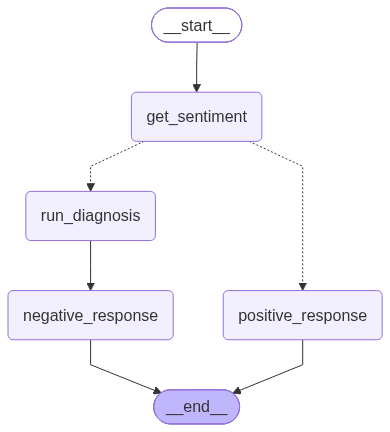

In [57]:
workflow

In [56]:
initial_state = {
    'review': "I don't like this product. It is terrible and I will never buy it again."
}
workflow.invoke(initial_state)

{'review': "I don't like this product. It is terrible and I will never buy it again.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': 'Subject: We\'re Here to Help\n\nHi there,\n\nThank you for reaching out to us, and I\'m sorry to hear that you\'ve had an experience that left you feeling disappointed. Even though things aren\'t urgent on your end, I want you to know that your concerns matter to us just as much.\n\nI understand that "other" issues can sometimes be the trickiest to pin down or explain, and it can be frustrating when something doesn\'t quite fit into a neat category—especially when it impacts your overall experience with us. Please know that I\'m fully here to listen and help sort this out, however long it takes.\n\nTo make sure I can assist you in the best way possible, could you share a bit more detail about what\'s been going on? Any specifics—what happened, when you noticed it, or what outco